# Burned area: does an earlier or later "after" date matter?

This notebook compares two burned-area maps that use the **same before image
(2025-07-07)** but a different **after image**:

- an **earlier** clear date, 2025-09-25
- a **later** clear date, 2025-10-15

The worry is that by mid-October, normal seasonal browning (leaves turning,
fields harvested) can look like a burn to the model. We test that by checking
each map against the **official fire records** (ICNF).

Important fairness step: we only count fires that **actually happened inside the
window** (started on or after the before image and ended on or before the after
image). A fire from last spring is already burnt in the before image, and a fire
in November has not happened yet, so neither one is something the model could
detect in that window.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import contextily as ctx

# Put the repo root on the path so we can load the project's config helper.
for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "utils" / "config.py").exists():
        sys.path.insert(0, str(_c))
        break

from utils.config import load_config

cfg = load_config()
print("repository root:", cfg.repo_root)

repository root: /Users/dgonzales22/Documents/PML Project/Machine-Learning


## Settings

In [2]:
BEFORE      = "2025-07-07"
AFTER_EARLY = "2025-09-25"
AFTER_LATE  = "2025-10-15"

PRED_DIR  = cfg.predictions_dir
LABELS    = cfg.repo_root / "data/processed/icnf_burned_labels_t29tpg_2025.tif"
ICNF_SHP  = cfg.repo_root / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
PT_BOUND  = cfg.repo_root / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg"

PIX_HA = 0.01   # one 10 m x 10 m pixel covers 100 square metres = 0.01 hectares

def find_raster(after_date, kind):
    """Locate the full-tile burned/observed map for a given after date."""
    a = after_date.replace("-", "")
    b = BEFORE.replace("-", "")
    hits = sorted(PRED_DIR.glob(f"T29TPG*{b}_{a}_{kind}.tif"))
    if not hits:
        raise FileNotFoundError(
            f"No '{kind}' map for after={after_date}. Run the inference first, e.g.\n"
            f"  python -m inference.run --device cpu "
            f"--before-date {BEFORE} --after-date {after_date}"
        )
    if len(hits) == 1:
        return hits[0]
    def coverage(p):
        with rasterio.open(p) as r:
            return int((r.read(1) != 255).sum())
    return max(hits, key=coverage)

def read(path):
    with rasterio.open(path) as r:
        return r.read(1)

## Load the maps

Each map uses value 1 for burned, 0 for not burned, and 255 for "no data".
The "observed" map tells us which pixels both images could actually see (no
clouds or gaps), so we only score those. We also read the label raster just to
get the study-area footprint.

In [3]:
burned = {d: read(find_raster(d, "burned"))   for d in (AFTER_EARLY, AFTER_LATE)}
obs    = {d: read(find_raster(d, "observed")) for d in (AFTER_EARLY, AFTER_LATE)}

labels = read(LABELS)
scored = labels != 255          # the study-area footprint (Portugal inside the tile)

with rasterio.open(LABELS) as _r:
    GRID_TRANSFORM = _r.transform
    GRID_SHAPE     = (_r.height, _r.width)
    EXTENT         = (_r.bounds.left, _r.bounds.right, _r.bounds.bottom, _r.bounds.top)

print("map size:", burned[AFTER_EARLY].shape)

map size: (6304, 10980)


## Ground truth, filtered to the timeframe

We read the official ICNF fire records and keep only fires that **started on or
after** the before image and **ended on or before** each after image. Those are
the only fires the model had a chance to detect. Each fire outline is shrunk by
one pixel (10 m) so that fuzzy edge pixels do not unfairly count against either
side. The result is one ground-truth map per after date.

In [4]:
fires = gpd.read_file(ICNF_SHP).to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]].copy()   # clip to the tile
fires["start"] = pd.to_datetime(fires["DH_Inicio"])
fires["end"]   = pd.to_datetime(fires["DH_Fim"])

def truth_mask(before_date, after_date, erode_m=10):
    """Burned ground truth from ICNF fires that occurred within the window."""
    sel = fires[(fires["start"] >= pd.Timestamp(before_date)) &
                (fires["end"]   <= pd.Timestamp(after_date))]
    geoms = [g for g in sel.geometry.buffer(-erode_m) if not g.is_empty]
    if not geoms:
        return np.zeros(GRID_SHAPE, dtype=bool)
    arr = rasterize([(g, 1) for g in geoms], out_shape=GRID_SHAPE,
                    transform=GRID_TRANSFORM, fill=0, dtype="uint8")
    return arr.astype(bool)

real = {d: truth_mask(BEFORE, d) for d in (AFTER_EARLY, AFTER_LATE)}
for d in (AFTER_EARLY, AFTER_LATE):
    n = ((fires["start"] >= pd.Timestamp(BEFORE)) & (fires["end"] <= pd.Timestamp(d))).sum()
    print(f"ground truth Jul 7 -> {d}: {n} fires, {real[d].sum() * PIX_HA:,.0f} ha")

ground truth Jul 7 -> 2025-09-25: 101 fires, 10,844 ha
ground truth Jul 7 -> 2025-10-15: 126 fires, 11,215 ha


## The numbers

For each after date: how much area the model flags as burned, and how that
splits into area that is on real fire ground (within the window) versus area
that is not.

In [5]:
rows = []
for d in (AFTER_EARLY, AFTER_LATE):
    flagged = burned[d] == 1
    trusted = flagged & (obs[d] == 1) & scored
    on  = int((trusted &  real[d]).sum())
    off = int((trusted & ~real[d]).sum())
    rows.append({
        "after_date":  d,
        "flagged_ha":  flagged.sum() * PIX_HA,
        "truth_ha":    real[d].sum() * PIX_HA,
        "on_fire_ha":  on  * PIX_HA,
        "not_fire_ha": off * PIX_HA,
        "pct_on_fire": 100 * on / max(on + off, 1),
    })

table = pd.DataFrame(rows).set_index("after_date").round(0)
table

,flagged_ha,truth_ha,on_fire_ha,not_fire_ha,pct_on_fire
after_date,,,,,
2025-09-25,23530.0,10844.0,9707.0,13823.0,41.0
2025-10-15,29211.0,11215.0,9099.0,20112.0,31.0


## Chart 1: what each map flags as burned

Each bar is split into the part that lands on real fire ground (red) and the
part that does not (tan, the likely seasonal browning). The dashed line over
each bar is the fire that actually happened in that window.

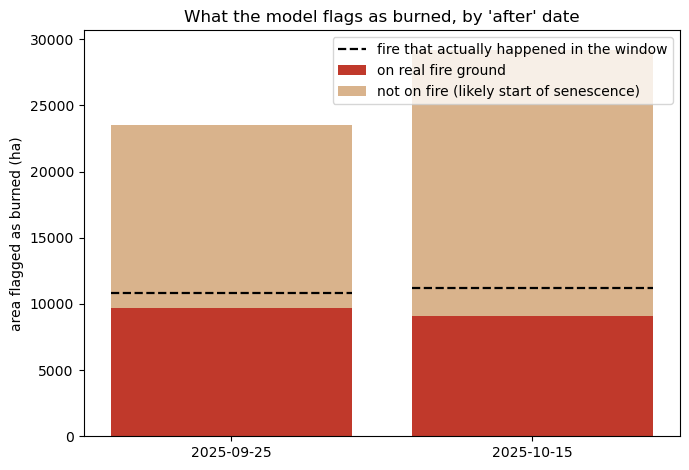

In [6]:
dates = list(table.index)
on    = table["on_fire_ha"].values
off   = table["not_fire_ha"].values
truth = table["truth_ha"].values

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.bar(dates, on,  label="on real fire ground",                 color="#c0392b")
ax.bar(dates, off, bottom=on, label="not on fire (likely start of senescence)", color="#d9b38c")
for i, t in enumerate(truth):
    ax.hlines(t, i - 0.4, i + 0.4, color="black", lw=1.6, linestyles="dashed")
ax.plot([], [], "k--", lw=1.6, label="fire that actually happened in the window")

ax.set_ylabel("area flagged as burned (ha)")
ax.set_title("What the model flags as burned, by 'after' date")
ax.legend()
plt.tight_layout()
plt.show()

## Overlay: prediction against the official records

These maps lay the model's prediction and the timeframe-filtered records on top
of each other, over a light basemap, with the Portugal boundary (no buffer):

- **violet**: the model and the records both say burned (they agree)
- **red**: the model says burned, but the records do not (likely false alarm)
- **blue**: the records say burned, but the model missed it

In [ ]:
PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")

def confusion_layers(after_date):
    m = (obs[after_date] == 1) & scored
    p = (burned[after_date] == 1) & m
    t = real[after_date] & m
    return (p & t), (p & ~t), (~p & t)      # overlap, predicted only, records only

def pool_or(a, k=8):
    H = (a.shape[0] // k) * k
    W = (a.shape[1] // k) * k
    return a[:H, :W].reshape(H // k, k, W // k, k).max(axis=(1, 3))

VIOLET = (0.55, 0.20, 0.65); RED = (0.84, 0.19, 0.15); BLUE = (0.26, 0.45, 0.85)

def overlay_rgba(after_date, k=8, alpha=0.9):
    tp, fp, fn = confusion_layers(after_date)
    TP, FP, FN = pool_or(tp, k), pool_or(fp, k), pool_or(fn, k)
    rgba = np.zeros(TP.shape + (4,))
    for mask, color in [(FN, BLUE), (FP, RED), (TP, VIOLET)]:
        rgba[mask, :3] = color
        rgba[mask, 3]  = alpha
    return rgba

def plot_overlay(after_date, title):
    """Draw one overlay map with a light basemap, the Portugal boundary,
    and the legend in the north-west corner (over Spain, not over the data)."""
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3]); ax.set_aspect("equal")
    try:
        ctx.add_basemap(ax, crs="EPSG:32629",
                        source=ctx.providers.CartoDB.Positron, attribution_size=6)
    except Exception as e:
        ax.set_facecolor("#f5f5f5"); print("basemap unavailable:", e)
    ax.imshow(overlay_rgba(after_date), extent=EXTENT, origin="upper",
              interpolation="nearest", zorder=3)
    PT.boundary.plot(ax=ax, color="black", linewidth=0.9, zorder=4)
    ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{title}   (before {BEFORE}, after {after_date})")
    legend = [
        mpatches.Patch(color=VIOLET, label="overlap: model and records agree"),
        mpatches.Patch(color=RED,    label="predicted only (likely false alarm)"),
        mpatches.Patch(color=BLUE,   label="records only (model missed)"),
        Line2D([0], [0], color="black", lw=0.9, label="Portugal boundary (no buffer)"),
    ]
    ax.legend(handles=legend, loc="upper left", fontsize=9, framealpha=0.95)
    plt.tight_layout(); plt.show()

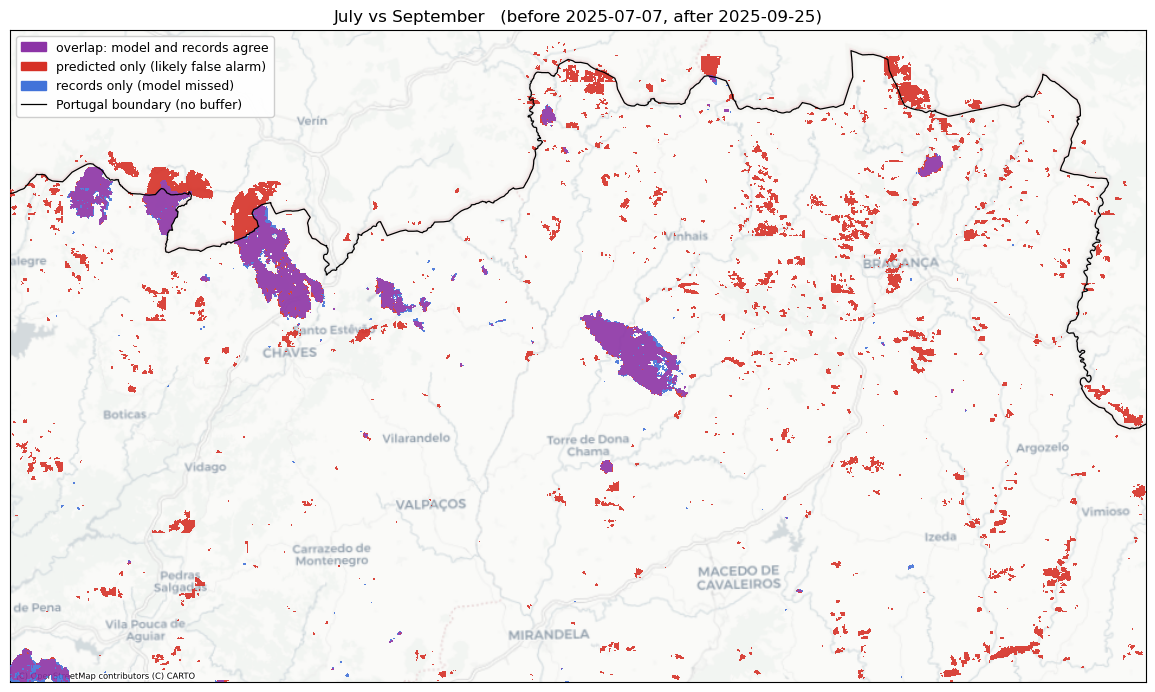

In [9]:
plot_overlay(AFTER_EARLY, "July vs September")

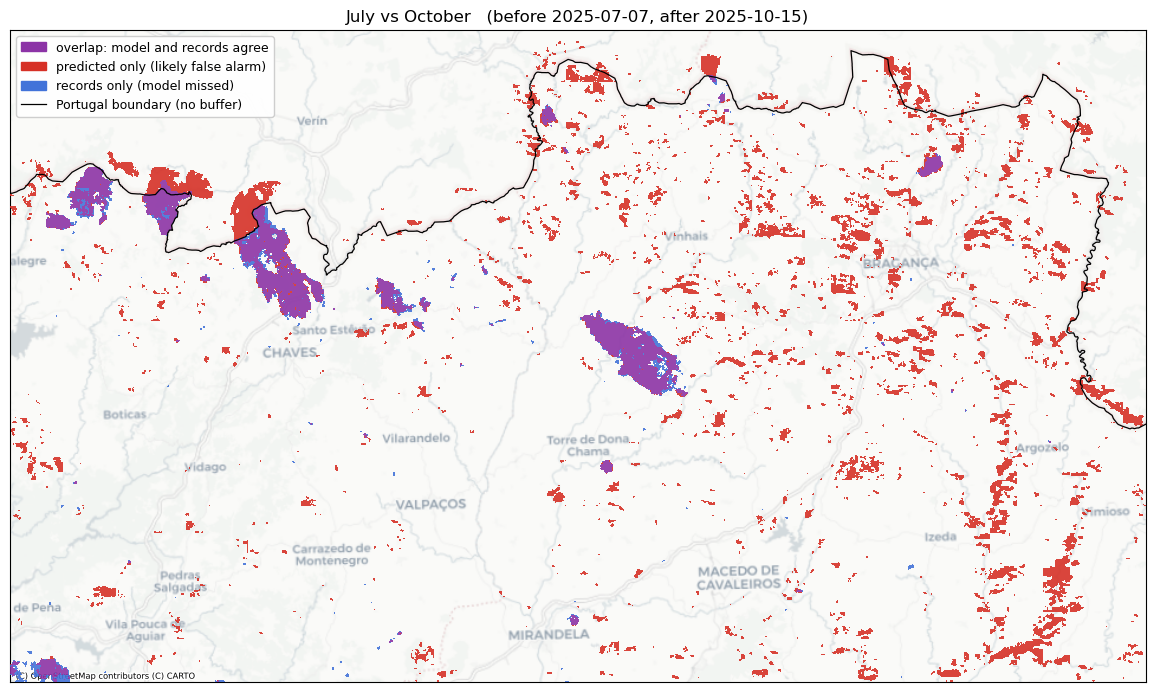

In [10]:
plot_overlay(AFTER_LATE, "July vs October")